## 6. 卷积神经网络

- 在第三章和第四章的内容中，我们处理了FashionMnist这个数据集，但当时无论是单层的线性、非线性神经网络都未能很好地捕捉图像真正的先验信息和特征，联想到图像这一信息载体，很显然的一个特征就是相邻像素之间的相互关联性，利用这部分先验知识往往能获得更好的空间结构信息。

- 本章就会介绍一类几乎可以说是针对于图像数据而设计的网络，即卷积神经网络(convolutional neural network,CNN),围绕图像展开的一系列计算机视觉任务，如图像识别、目标检测或语义分割等任务都常常以这类网络为基础。

- 卷积的操作非常适合在GPU上并行计算，除了上面提到的图像数据，卷积神经网络也常常用于序列结构的任务、图结构数据和推荐系统中。

### 6.1 从全连接层到卷积

- MLP在面对一些任务时可能会比较棘手：例如有一张百万级像素的图像，即使我们设置隐藏层的维度是1000，单层的全连接层的weight数量也将达到十亿级别，这几乎和现代的小型LLM达到一个级别，但如此庞大的单层数据规模可能根本无法学习到良好的图像特征，在同等的参数规模下，其他的网络结构能捕获更大范围、更多层次、更多类别的信息，因此，我们迫切的需要利用当前数据本身的特性，CNN就是这类创造性方法的一种。

#### 6.1.1 不变性

- 围绕上面所说的内容，我们应该去思考图像数据中存在什么样的先验结构信息：
    - 我们得到的结论非常简单也非常直观，即**如果我们试图完成一个从图像中寻找某个特定物体的任务，我们选择的方法一定要和物体的位置无关**，例如，我们可以将图像分割成多块，按照相同的方式类似递归的去寻找这个物体，而在递归函数中，寻找这个行为一定是相同的，换言之，在图像的哪个位置我们去寻找都需要一样的方式方法
    - 我们总结上面的内容：即**如果要去寻找一种适合图像数据的网络结构设计方法，要么一定要满足平移不变性，即不管检测对象出现在图像哪里，网络都需要对这个位置做出相同的反应**
    - 后面的局部性我认为用识别这个任务说有点牵强，我换种说法：图像数据本身的很多浅显的信息就集中在局部，例如我们如果看到一张图像中有几朵云，那么大概率离这里很近的位置就会有一个太阳or月亮，这是能在不用看完整张图像就能知道的现象；但如果我问你这张图像表达了拍摄者什么样的构思，你就不能只用局部来回答我了，你得看完整张图像并对图像中展示的画面、意境、构图有一个全面的认知，也即这里的**网络前期不应过度在意较远区域的关系，最终我们能聚合这些局部特征，对整个图像级别进行预测**

#### 6.1.2 MLP的限制

- d2l这里用一个形象化的公式描述了二维图像中的全连接层公式，大致的要点就是将原始的全连接层的一维输入改为了二维图像的形式，相应的，偏置也调整为了二维的张量形式，权重则改写为了四维的形式
    - 具体来说，公式如下：
    $$
        \begin{aligned}
        [\mathbf{H}]_{i,j} &= [\mathbf{U}]_{i,j} + \sum_{k} \sum_{l} [\mathbf{W}]_{i,j,k,l} [\mathbf{X}]_{k,l} \\
        &= [\mathbf{U}]_{i,j} + \sum_{a} \sum_{b} [\mathbf{M}]_{i,j,a,b} [\mathbf{X}]_{i+a,j+b}.
        \end{aligned}
    $$
    - 第二行的等式相当于在最后的输出数据上进行平移，此时输入的二维数据和权重都可以以平移的形式表示
    - 我们可以进一步分析这个公式的含义：
        - 首先其满足平移不变性，用第二行的形式表示之后，真实的运算和具体的二维数据位置无关，真正影响(i,j)位置的输出数据像素值的只有相对坐标的a和b，运算的实质就是用系数对位置(i,j)附近的像素值进行加权计算
        - 既然前面满足了平移不变性，接下来要考虑局部性的实现，在这个公式很好做到，即远离计算出的输出像素点(i,j)的位置不应该对输出数据造成影响，即(a,b)过大的情况权重应设置为0
    - 此时我们将公式改写为：
    $$
        [\mathbf{H}]_{i,j} = u + \sum_{a=-\Delta}^{\Delta} \sum_{b=-\Delta}^{\Delta} [\mathbf{V}]_{a,b} [\mathbf{X}]_{i+a,j+b}.
    $$
    - 上述公式实质上就是一个卷积运算，和参数量极大的全连接层相比，卷积运算显著减少了参数量，原因在于局部性的限制+相对位置的加权计算(和具体的位置无关)


- 本质上说，上面总结出的二维图像运算并不是数学上严格的卷积，真实的卷积是
$$
    (f * g)(\mathbf{x}) = \int f(\mathbf{z}) g(\mathbf{x} - \mathbf{z}) \, d\mathbf{z}. 
$$
$$
    (f * g)(i,j) = \sum_{a} \sum_{b} f(a,b) g(i-a, j-b).
$$

- 但如果忽略一些具体的符号，可以体会到这里的图像卷积和真实卷积在运算的意义上是高度一致的

- 接下来d2l中提到了通道的概念，从比较形象化的角度来说，这件事就是：我们想象最基础的图像分解，可以分解为RGB三个颜色通道，因为色光加色法的存在导致任意像素的颜色都可以分解为RGB的组合，所以我们在真正的通过网络学习一些图像特征时，可以从RGB分解图像的角度来考虑，例如，我们寻找某个红色的帽子，我们很大概率会在R值很大的像素点寻找到；从更抽象的角度来说，当网络能学习到一些更为高级的特征时，我们也可以加以利用，例如一些特征能提取到图像中存在的事物、风格、布局，我们的一些任务很有可能是围绕这些特征存在的，因此在原始卷积的基础上扩充维度和通道的概念非常有必要

### 6.2 图像卷积

#### 6.2.1 互相关运算

- 在这里举了一个最简单的单通道3 * 3图像经过2 * 2卷积运算的例子,具体的运算如下：
- ![6.1](./images/chapter6/1.png)
- 具体运算不多赘述，我们主要关注最终结果的维度，最后得到的输出结果是2*2的数据，总结这种单通道的卷积运算，可以发现如果将原始图像维度设置为(x,y),卷积核的大小是(a,b)，最终得到的结果就是(x-a+1, y-b+1)
- 上面运算说明，在最基础的情况下，卷积得到的结果维度非常固定，因此在卷积中需要引入其他非常多的方式来改变数据维度

In [6]:
import torch
from torch import nn

# 通过计算公式实现基础的手动卷积

def corr2d(X,K):
    h,w = K.shape
    Y = torch.zeros((X.shape[0]-h+1, X.shape[1]-w+1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i,j] = (X[i:i + h,j:j + w] * K).sum()
    return Y

X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
K = torch.tensor([[0.0, 1.0], [2.0, 3.0]])
print(corr2d(X, K))

tensor([[19., 25.],
        [37., 43.]])


In [7]:
class Conv2d(nn.Module):
    def __init__(self, kernal_size):
        super().__init__()
        self.weight = nn.Parameter(torch.rand(kernal_size))
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self,X):
        return corr2d(X, self.weight) + self.bias

In [8]:
X = torch.ones((6,8))
X[:, 2:6] = 0
print(X)

# 上述二维数据中中间的四列都是0，其余都是1

K = torch.tensor([[1.0, -1.0]])
# 之所以设置这样一个(1,2)的卷积核，原因在于他只在水平维度上进行计算，当连续的两个像素点数值相同时，卷积运算结果就会是0，否则就可以说明水平相邻像素数值不同

Y = corr2d(X, K)
print(Y)

# 上述的例子说明了针对特定的特征提取，一个好的卷积核在某种程度上能帮助提取信息

tensor([[1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.]])
tensor([[ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.]])


#### 6.2.4 学习卷积核

- 对于复杂的特征，需要的提取特征的卷积核就需要更加复杂，对于复杂的卷积核就没办法手动设计了，需要通过学习的方式来更新

In [ ]:
conv2d = nn.Conv2d(1,1, kernel_size=(1, 2), bias=False)

# 利用之前定义的变量X和Y
X = X.reshape((1,1,6,8))
Y = Y.reshape((1,1,6,7))
lr = 3e-2

for i in range(10):
    Y_hat = conv2d(X)
    l = (Y_hat - Y) ** 2
    conv2d.zero_grad()
    l.sum().backward()

    conv2d.weight.data[:] -= lr * conv2d.weight.grad
    if (i + 1) % 2==0:
        print(f'epoch {i+1}, loss {l.sum():.3f}')

print(conv2d.weight.data.reshape((1, 2))) # 非常接近(1,-1)

epoch 2, loss 15.345
epoch 4, loss 5.357
epoch 6, loss 2.038
epoch 8, loss 0.809
epoch 10, loss 0.327
tensor([[ 1.0486, -0.9310]])


#### 6.2.5 互相关和卷积

- 真正在本章中涉及的相关运算是互相关运算而非真实的卷积运算，但幸运的是在学习改变的情况下，同样的计算方式能让这两者画上"计算意义上的等号"

#### 6.2.6 特征映射和感受野

- 这里引入了特征和特征映射的概念，连续的计算中输出的卷积层有时被称为**特征映射**

- 在卷积神经网络中，对于某一层的任意元素，**感受野**指的是在前向传播期间可能影响x计算的所有元素
    - 这里有一个点即，感受野在深度卷积网络中是不断扩张的，因此当一个特征图中的元素需要检测更广区域的输入特征时，可以构建一个更深的网络

### 6.3 填充和步幅

- 前面的一个例子中，基础卷积很大的问题是当卷积核和输入数据的维度确定时，输出数据的维度也唯一确定，但很多时候我们希望输出表征的维数满足我们的需求，因此本节的填充和步幅就能解决这个问题

#### 6.3.1 填充

- 在应用多层卷积时,我们常常丢失边缘像素。由于我们通常使用小卷积核,因此对于任何单个卷  积,我们可能只会丢失几个像素。但随着我们应用许多连续卷积层,累积丢失的像素数就多了。解决这个问  题的简单方法即为填充(padding):在输入图像的边界填充元素(通常填充元素是0)

- 填充的示意图如下，即现在在原始输入数据的基础上外层添加了一圈0 ![6.2](./images/chapter6/2.png)

- 由于引入了填充，我们重新梳理卷积维度的关系式，现在的输入数据维度是(x,y)，卷积核大小是(a,b)，填充的大小是(m,n)，最终得到的大小是(x-a+m+1)*(y-b+n+1)
    - 这里要注意两个点，m和n指的是单个维度上总的填充数,即左右各会填充一半的像素大小
    - 这个公式很好推广，因为可以将填充看成是扩大的输入图像

- 下面是示例：

In [12]:
# torch中原生的conv需要具有batch_size和特征两个维度，引入一个函数处理数据

import torch
from torch import nn

def comp_conv2d(conv2d, x):
    x = x.reshape((1,1)+x.shape)
    y = conv2d(x)
    return y.reshape(y.shape[2:])

conv2d = nn.Conv2d(1,1,kernel_size=3,padding=1)

x = torch.rand(size=(8,8))
print(comp_conv2d(conv2d,x).shape)

torch.Size([8, 8])


#### 6.3.2 步幅

- 在计算互相关时,卷积窗口从输入张量的左上角开始,向下、向右滑动。在前面的例子中,我们默认每次滑动  一个元素。但是,有时候为了高效计算或是缩减采样次数,卷积窗口可以跳过中间位置,每次滑动多个元素

- 每次滑动元素的数量称为**步幅**(stride)

- 引入步幅之后，输出数据的维度表达式又需要进一步更改，具体的公式如下：

- ![6.3](./images/chapter6/3.png)

- 上面的这个公式比d2l中的更清晰，要注意这里的padding定义和d2l不一样

In [ ]:
conv2d = nn.Conv2d(1, 1, kernel_size=3, padding=1, stride=2)
print(comp_conv2d(conv2d,x).shape) # (4,4)

torch.Size([4, 4])


### 6.4 多输入多输出通道

- 前面也提到通道的引入对于处理复杂的特征提取任务是非常重要的，因此这一节主要解决多通道问题

#### 6.4.1 多输入通道

- 当输入包含多个通道时,需要构造一个与输入数据具有相同输入通道数的卷积核,以便与输入数据进行互相关运算

- 多通道的计算原则就是各通道分开计算，最终通道求和得到最终结果

- 具体的计算方式示例如下：![6.4](./images/chapter6/4.png)

- 具体实现如下：

In [14]:
import torch

def corr2d_multi_in(X,K):
    return sum(corr2d(x,k) for x,k in zip(X,K))

X = torch.tensor([[[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]],  [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0], [7.0, 8.0, 9.0]]])
K = torch.tensor([[[0.0, 1.0], [2.0, 3.0]], [[1.0, 2.0], [3.0, 4.0]]])

# X的维度是[2,3,3]，K的维度是[2,2,2]

print(corr2d_multi_in(X,K))

tensor([[ 56.,  72.],
        [104., 120.]])


#### 6.4.2 多输出通道

- 在前面一小节的基础上，我们学会了处理多通道输入的处理方式，但上述的计算结果仍然是一个通道，因为最后算出来的各通道还需要进行一个加和

- 考虑到连续的卷积网络，我们希望经过卷积操作的结果也具有多通道的特征，这也能从一定的程度增加特征的复杂度

- 前面的corr2d_multi_in处理了多个输入通道的卷积和数据，多输出通道只需要在上述的基础上增加一个卷积核的输出维度在最前面即可，下面是具体的实现：

In [18]:
def corr2d_multi_in_out(X, K):
    return torch.stack([corr2d_multi_in(X,k) for k in K],0)

K = torch.tensor([[[0.0, 1.0], [2.0, 3.0]], [[1.0, 2.0], [3.0, 4.0]]])
K = torch.stack((K, K+1, K+2),0)
print(K.shape)

print(corr2d_multi_in_out(X, K))

torch.Size([3, 2, 2, 2])
tensor([[[ 56.,  72.],
         [104., 120.]],

        [[ 76., 100.],
         [148., 172.]],

        [[ 96., 128.],
         [192., 224.]]])


#### 6.4.3 1*1卷积层

- 本小节主要讨论形状为1*1的卷积核，这样的形状貌似和卷积的精神背道相驰，毕竟卷积的初衷就是通过加权和的计算方式提取周边像素的信息

- 但1*1的卷积在深度神经网络中使用非常广泛，主要的作用就在于**通道融合上**

- 下面的图表示了1*1的卷积运算方式：![6.5](./images/chapter6/5.png)

- 下面的代码展示了1*1的卷积运算方式：

In [ ]:
def corr2d_multi_in_out_1x1(X,K):
    c_i, h, w = X.shape
    c_o = K.shape[0]

    X = X.reshape(c_i, h*w)
    K = K.reshape(c_o, c_i)
    Y = torch.matmul(K,X)
    return Y.reshape(c_o, h, w)

# 这里就说明了1*1的卷积可以通过全连接方式计算，也从一定程度上说明了在前面的根据全连接公式推广到卷积的合理性

X = torch.normal(0, 1, (3, 3, 3))
K = torch.normal(0, 1, (2, 3, 1, 1))

Y1 = corr2d_multi_in_out_1x1(X, K)
Y2 = corr2d_multi_in_out(X, K)
assert float(torch.abs(Y1 - Y2).sum()) < 1e-6

# 未报错说明全连接的实现方式等价于nn.Conv2d()

### 6.5 汇聚层

- 卷积的运算方式是为了实现前面提到的两个目标：局部不变性和局部捕捉特征的能力

- 在一个使用卷积提取特征的网络中，我们期望前期的卷积主要关注局部的特征，底层的特征通常保持某种程度上的平移不变性，随着计算的深入，映射越来越粗糙，也越来越能学习全局的特征

- 因此，我们希望在处理图像时，逐渐降低隐藏层表示的空间分辨率和聚集信息，让神经元对敏感的感受野越来越大

- 因此，本节引入**汇聚层**，汇聚层的目标是：降低卷积层对位置的敏感性，同时降低对空间降采样表示的敏感性，这句话的理解在下面慢慢解释

#### 6.5.1 最大汇聚层和平均汇聚层

- 汇聚层的计算方式和卷积类似，也是指定一个窗口，然后在整张图像中华东，遍历计算输出

- 汇聚层不包含参数，完成的是一个具有确定性的运算，常见的计算方式就是最大汇聚和平均汇聚

- 最大汇聚的计算方式如图所示：![6.6](./images/chapter6/6.png)

- 从上面的例子中我们可以很好的理解汇聚层目标的前半句，在未引入汇聚层的卷积运算中，比方说我们要提取一个小兔子的信息，这个小兔子出现在(2,2)和(2,3)，大概率这两次的卷积运算是不同的，这不符合我们希望的局部不变性，我们通过一个合适的窗口将这个范围内的特征再进行一次整合，就能很好的做到局部不变

- 下面是具体的实现：

In [24]:
import torch
from torch import nn

def pool2d(X, pool_size, mode="max"):
    p_h, p_w = pool_size
    Y = torch.zeros(X.shape[0]-p_h+1, X.shape[1]-p_w+1)
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            if mode == "max":
                Y[i,j] = torch.max(X[i:i+p_h,j:j+p_w])
            if mode == "mean":
                Y[i,j] = torch.mean(X[i:i+p_h,j:j+p_w])

    return Y

X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
print(pool2d(X,(2,2)))
print(pool2d(X,(2,2),"mean"))

tensor([[4., 5.],
        [7., 8.]])
tensor([[2., 3.],
        [5., 6.]])


#### 6.5.2 填充和步幅

- 汇聚层同样可以改变输出形状，因此也可以在汇聚层中设置填充和步幅

- 下面是代码示例：

In [29]:
X = torch.arange(16, dtype=torch.float32).reshape((1, 1, 4, 4))
print(X)

pool2d = nn.MaxPool2d(3) # 注意写法
print(pool2d(X))

# 注意这里的计算结果，10->[1,1,1]，为什么是这样的结果呢，因为这里的nn.MaxPool2d(3)中的3其实不光指代了汇聚窗口的大小，并且指定了步幅
# 很好的一个理解就是nn中默认的池化方式是不重叠的，即我采了一个3*3的窗口，下次往右往下滑动的过程中我不希望光顾之前已经参与计算的任何一个像素

# 作为对比，我们指定步幅
pool2d = nn.MaxPool2d(3, padding=1, stride=2)
print(pool2d(X))

# 没有参数的情况下，我们也可以通过指定一个元组的形状来控制矩形的汇聚窗口
pool2d = nn.MaxPool2d((2, 3), stride=(2, 3), padding=(0, 1))
print(pool2d(X))

tensor([[[[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.],
          [ 8.,  9., 10., 11.],
          [12., 13., 14., 15.]]]])
tensor([[[[10.]]]])
tensor([[[[ 5.,  7.],
          [13., 15.]]]])
tensor([[[[ 5.,  7.],
          [13., 15.]]]])


#### 6.5.3 多个通道

- 考虑到数据存在多个通道，因此汇聚层也需要建立在多通道基础上

In [ ]:
X = torch.arange(16, dtype=torch.float32).reshape((1, 1, 4, 4))

X = torch.cat((X, X + 1), 1)
print(X.shape)
print(X)

pool2d = nn.MaxPool2d(3,padding=1,stride=2)
print(pool2d(X))
# MaxPool2d自动完成多通道计算


torch.Size([1, 2, 4, 4])
tensor([[[[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.],
          [ 8.,  9., 10., 11.],
          [12., 13., 14., 15.]],

         [[ 1.,  2.,  3.,  4.],
          [ 5.,  6.,  7.,  8.],
          [ 9., 10., 11., 12.],
          [13., 14., 15., 16.]]]])
tensor([[[[ 5.,  7.],
          [13., 15.]],

         [[ 6.,  8.],
          [14., 16.]]]])


### 6.6 卷积神经网络(LeNet)

- LeNet是最早的卷积神经网络之一，此模型是当时贝尔实验室的研究员Yann LeCun提出的，因此以他的名字命名

- Yann Lecun目前已成为世界模型的领导人之一，拿了图灵奖，相信是每个AI人都知道的泰斗级人物

- LeNet在当时取得了和SVM相当的性能

#### 6.6.1 LeNet

- 从结构上看，LeNet-5由两个部分组成：
    - 两个卷积层组成的卷积编码器
    - 三个全连接层组成的全连接层密集块

- 具体的结构如图：![6.7](./images/chapter6/7.png)

- 每个卷积块中的基本单元是一个卷积层、一个sigmoid激活函数和平均汇聚层,当时类似ReLU和最大汇聚层还没出现

- 卷积到全连接层需要有一个展平操作，即维持batch_size的维度，将其他的三个维度(通道、高、宽)展平到一个维度上

- 具体实现如下：

In [2]:
import torch
from torch import nn

net = nn.Sequential(
    nn.Conv2d(1,6,kernel_size=5,padding=2), # 这里kernel_size=5+padding=2的写法可以保证卷积的数据维度不变
    nn.Sigmoid(),
    nn.AvgPool2d(2), # 等同于AvgPool2d(kernel_size=2,stride=2)的写法
    nn.Conv2d(6,16,kernel_size=5),
    nn.Sigmoid(),
    nn.AvgPool2d(2),
    nn.Flatten(), # 更加具体的用法就是指定start_dim和end_dim这两个参数控制参与flatten的维度
    nn.Linear(16*5*5, 120),
    nn.Sigmoid(),
    nn.Linear(120, 84),
    nn.Sigmoid(),
    nn.Linear(84,10)
)

X = torch.rand(size=(1, 1, 28, 28), dtype=torch.float32)

for layer in net:
    X = layer(X)
    print(layer.__class__.__name__, 'output shape: \t',X.shape)

Conv2d output shape: 	 torch.Size([1, 6, 28, 28])
Sigmoid output shape: 	 torch.Size([1, 6, 28, 28])
AvgPool2d output shape: 	 torch.Size([1, 6, 14, 14])
Conv2d output shape: 	 torch.Size([1, 16, 10, 10])
Sigmoid output shape: 	 torch.Size([1, 16, 10, 10])
AvgPool2d output shape: 	 torch.Size([1, 16, 5, 5])
Flatten output shape: 	 torch.Size([1, 400])
Linear output shape: 	 torch.Size([1, 120])
Sigmoid output shape: 	 torch.Size([1, 120])
Linear output shape: 	 torch.Size([1, 84])
Sigmoid output shape: 	 torch.Size([1, 84])
Linear output shape: 	 torch.Size([1, 10])


In [3]:
# 之前的绘图工具复用

import matplotlib.pyplot as plt
from matplotlib_inline import backend_inline

def set_axes(axes,xlabel,ylabel,xlim,ylim,xscale,yscale,legend):
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.grid()
    if legend:
        axes.legend(legend)

class Animator:
    def __init__(self, xlabel=None, ylabel=None, legend=None,
                 xlim=None, ylim=None, xscale='linear', yscale='linear',
                 fmts=('-','m--','g-.','r:'),nrows=1,ncols=1,
                 figsize=(3.5,2.5)):
        if legend is None:
            legend = []
        backend_inline.set_matplotlib_formats("svg")
        self.fig, self.axes = plt.subplots(nrows,ncols,figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes,]
        self.config_axes = lambda:set_axes(
            self.axes[0],xlabel,ylabel,xlim,ylim,xscale,yscale,legend
        )
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self,x,y):
        if not hasattr(y,"__len__"):
            y = [y]
        n = len(y)
        if  not hasattr(x,"__len__"):
            x = [x] * n
        # self.X和self.Y这两个类其实是为了画出loss和在训练集和测试集上随着训练epoch的变化情况，因此长度就是3
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a,b) in enumerate(zip(x,y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x,y,fmt in zip(self.X,self.Y,self.fmts):
            self.axes[0].plot(x,y,fmt)
        self.config_axes() # 灵活运用lambda函数省去重复使用复杂函数
        display.display(self.fig)
        display.clear_output(wait=True) # display这个模块的引入主要是为了动态画出变化的过程 直接plot + show 无法实现这种动态变化的效果

loss 0.453, train acc 0.832, test acc 0.797
41868.8 examples/sec on cpu


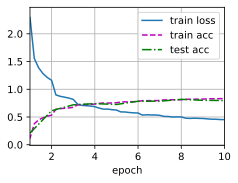

In [4]:
# 下面我们重回之前在chapter3 chapter4的部分对于Fashion-MNIST的相关组件，试试LeNet在其上面的表现

import time
import torchvision
from torch.utils import data
from torchvision import transforms
from IPython import display

def load_data_fashion_mnist(batch_size, resize=None):
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0,transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(root="./data",train=True,download=False,transform=trans)
    mnist_test = torchvision.datasets.FashionMNIST(root="./data",download=False,train=False,transform=trans)
    return data.DataLoader(mnist_train,shuffle=True,batch_size=batch_size),data.DataLoader(mnist_test,shuffle=True,batch_size=batch_size)

batch_size = 256

train_iter, test_iter = load_data_fashion_mnist(batch_size)

class Accumulator:
    def __init__(self,n):
        self.data = [0.0] * n

    def add(self,*args):
        self.data = [a + float(b) for a,b in zip(self.data,args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self,idx):
        return self.data[idx]

def try_gpu(i=0):
    if torch.cuda.device_count() >= i+1:
        return torch.device(f"cuda:{i}")
    return torch.device("cpu")

def accuracy(y_hat, y):
    if y_hat.shape[1] > 1 and len(y_hat.shape) > 1:
        y_hat = y_hat.argmax(axis=1) # torch.tensor的方法
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

class Timer:
    def __init__(self):
        self.time = []
        self.start()

    def start(self):
        self.tik = time.time()

    def stop(self):
        self.time.append(time.time()-self.tik)
        return self.time[-1]

    def avg(self):
        return sum(self.time) / len(self.time)

    def sum(self):
        return sum(self.time)

    def cumsum(self):
        return np.array(self.time).cumsum().tolist()

# 重新定义一个评估函数
def evaluate_accuracy_gpu(net, data_iter, device=None):
    if isinstance(net, nn.Module):
        net.eval()
        if not device:
            device = next(iter(net.parameters())).device

    metric = Accumulator(2)
    with torch.no_grad():
        for X,y in data_iter:
            if isinstance(X, list):
                X = [x.to(device) for x in X]
            # 这里的前一个逻辑是为后续的多个输入数据做铺垫
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(accuracy(net(X),y), y.numel())
    return (metric[0]/metric[1])

# 下面我们在第三章的训练函数基础上进一步升级训练函数
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)

    net.apply(init_weights)
    print("training on",device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(),lr=lr)
    loss = nn.CrossEntropyLoss()
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs],  legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = Timer(), len(train_iter)
    for epoch in range(num_epochs):
        metric = Accumulator(3)
        net.train()
        for i, (X,y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i+1)%(num_batches // 5) == 0 or i == num_batches-1:
                animator.add(epoch + (i+1) / num_batches, (train_l, train_acc, None))
        test_acc = evaluate_accuracy_gpu(net,test_iter)
        animator.add(epoch+1,(None,None,test_acc))
        print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '  f'test acc {test_acc:.3f}')
        print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '  f'on {str(device)}')

lr, num_epochs = 0.9, 10
train_ch6(net, train_iter, test_iter, num_epochs, lr, try_gpu())
